# Comparing Local Explanations

We focus on tabular data for regression.
- Local ALE (my contribution)
- LIME
- Ceteris Paribus Plots
- Counterfactuals

We implement all explainers ourselves.
- The Ceteris Paribus plot is self-explanatory, and is also known as an Individual Conditional Expectation (ICE) plot.
- We convert the implementation for LIME, which is originally for classificaiton, to a version for regression. We adapted from the LIME repository: [LIME Python implementation](https://github.com/marcotcr/lime/tree/ce2db6f20f47c3330beb107bb17fd25840ca4606).
- We implement permutation sampling for Shapley values, which is the standard sampling method used in practice. We also implement a version that uses antithetic variates.

In [59]:
import time

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

from cp import CeterisParibus
from ale import ALE
from lime import LIME
from shap import SHAP

from utils import bin_selection

In [60]:
# generate data
def generate_2d_data(n, sigma=0.05):
    Z = np.random.uniform(-np.sqrt(3), np.sqrt(3), n)
    epsilon = np.random.normal(0, sigma, n)
    X1 = Z
    X2 = Z + epsilon

    return np.vstack([X1, X2]).T

def generate_independent_2d_data(n):
    X1 = np.random.uniform(-np.sqrt(3), np.sqrt(3), n)
    X2 = np.random.uniform(-np.sqrt(3), np.sqrt(3), n)
    return np.vstack([X1, X2]).T

def generate_2d_data_normal(n, rho=0.5):
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]  # covariance matrix
    data = np.random.multivariate_normal(mean, cov, n)
    return data

def generate_3d_data(n, sigma=0.05):
    Z = np.random.uniform(1, 2, n)
    epsilon_1 = np.random.normal(0, sigma, n)
    epsilon_2 = np.random.normal(0, sigma, n)
    epsilon_3 = np.random.normal(0, sigma, n)
    X1 = Z + epsilon_1
    X2 = Z + epsilon_2
    X3 = Z + epsilon_3
    return np.vstack([X1, X2, X3]).T

def generate_mixed_data(n, num_categories=3):
    x1 = np.random.randint(0, num_categories, n)
    x2 = np.random.uniform(0, 1, n)
    return np.vstack([x1, x2]).T

In [61]:
x_explain = np.array([1, 1])
f = lambda x: x[:, 0] + x[:, 1] ** 2
n = 1000
X = generate_independent_2d_data(n)
X[0, :] = x_explain
y = f(X)
bins = bin_selection(n)

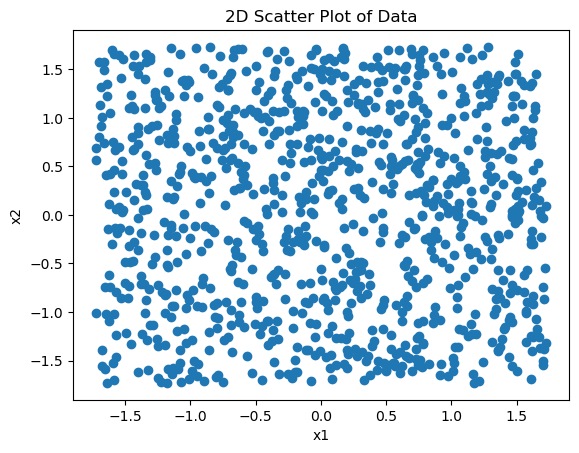

In [62]:
# 2d scatter plot
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Scatter Plot of Data")
plt.show()

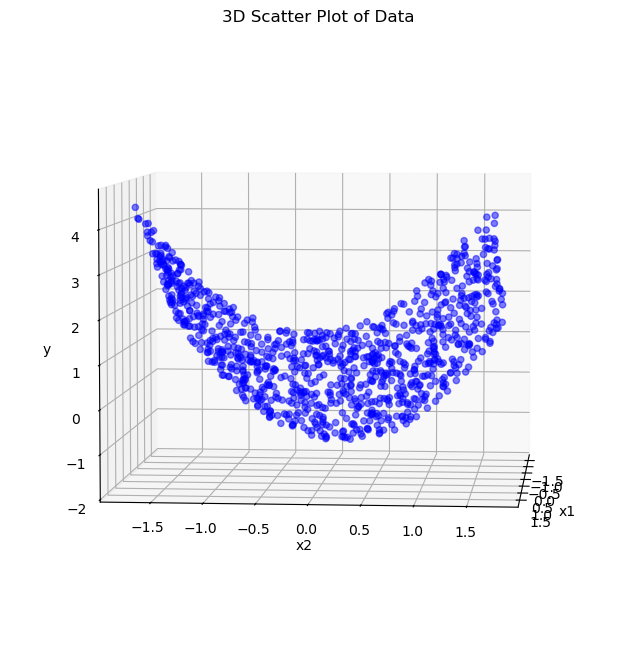

In [63]:
# 3d scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(5, 5)
ax.scatter(X[:, 0], X[:, 1], y, c='blue', marker='o', alpha=0.5)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('3D Scatter Plot of Data')
plt.show()

Feature | Value
-------------------
X1 | [1.]
X2 | [1.]
-------------------
Prediction: 2.0


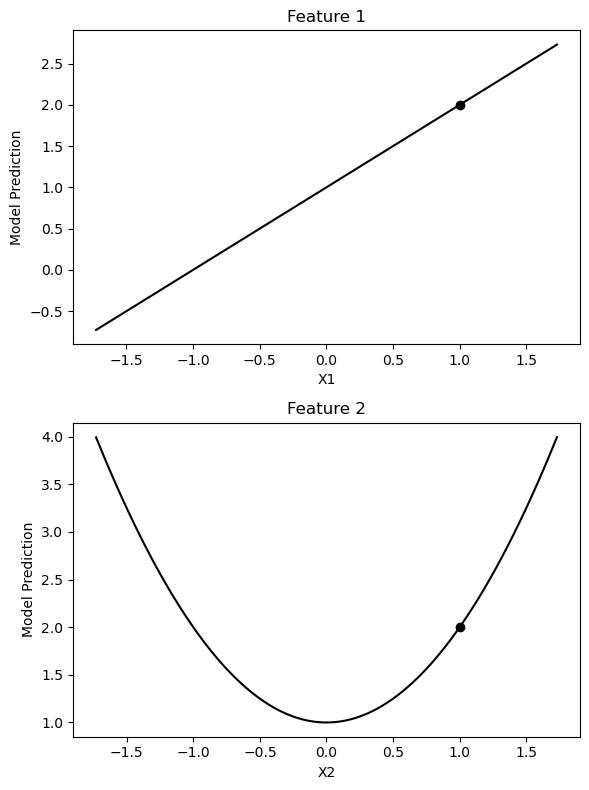

In [64]:
cp = CeterisParibus(f, X, bins=100)
cp.explain_local(0)

In [65]:
def plot_queried_points(X, query_points):
    plt.scatter(X[:, 0], X[:, 1], marker='o', label='Data Points', alpha=0.5)
    plt.scatter(query_points[:, 0], query_points[:, 1], marker='x', color='red', label='Queried Points')
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(f"Queried Points by Explanation (q: {len(query_points)}, n: {X.shape[0]})")
    plt.legend()
    plt.show()

## Visualizing Queried Points

x_bar 0.05056423008196357 rounded to 0.022892445522536328 [-1.72761915 -1.56887964 -1.40208327 -1.26920021 -1.131169   -0.98719215
 -0.81103245 -0.68140855 -0.52219986 -0.36951527 -0.23397421 -0.09680547
  0.02289245  0.15744179  0.26919388  0.39659312  0.54161509  0.65847153
  0.75469616  0.88779147  1.04804662  1.18834378  1.33897281  1.47031401
  1.607622    1.72928272]
E[X^2] estimated on edges:  1.0481587174493412
x_bar 0.05056423008196357 rounded to 0.022892445522536328 [-1.72761915 -1.56887964 -1.40208327 -1.26920021 -1.131169   -0.98719215
 -0.81103245 -0.68140855 -0.52219986 -0.36951527 -0.23397421 -0.09680547
  0.02289245  0.15744179  0.26919388  0.39659312  0.54161509  0.65847153
  0.75469616  0.88779147  1.04804662  1.18834378  1.33897281  1.47031401
  1.607622    1.72928272]
E[X^2] estimated on edges:  1.0481587174493412


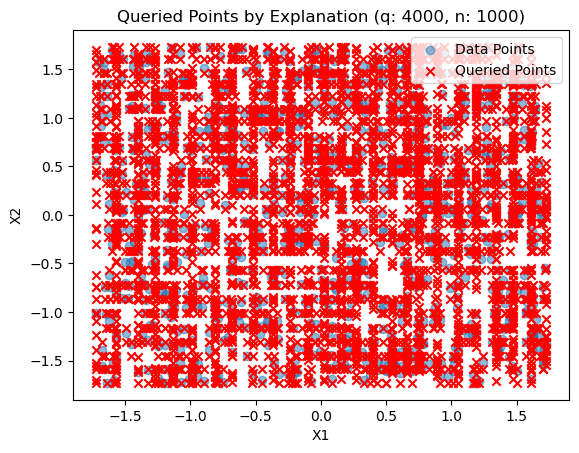

In [66]:
ale = ALE(f=f, X=X, bins=bins, verbose=False)
ale.explain()
ale.explain_local(0)
plot_queried_points(X, ale.get_query_points())

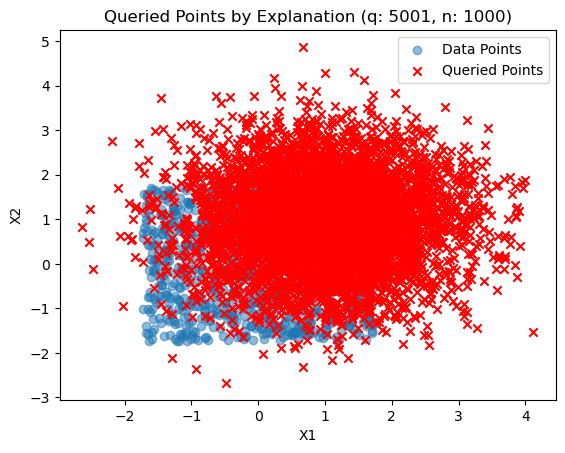

In [67]:
lime = LIME(f, X, verbose=False, kernel_width=0.01)
lime.explain_local(0)
plot_queried_points(X, lime.get_query_points())

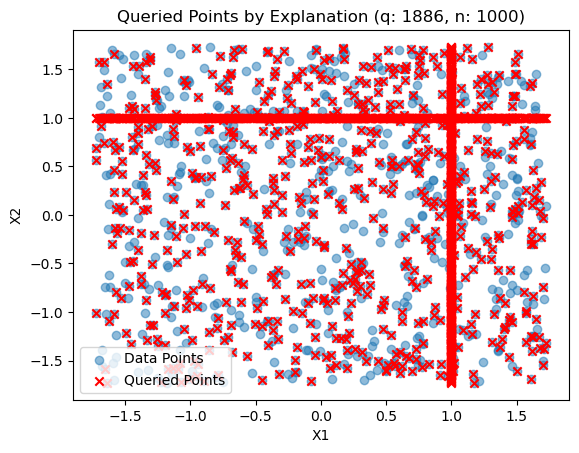

In [68]:
shap = SHAP(f, X, verbose=False)
shap.explain_local(0, num_samples=1000)
plot_queried_points(X, shap.get_query_points())

In [69]:
def replicate_compared_local_explanations(dgp, f, x_explain, n=200, m=50, config=None):
    default_config = {
        "bins": bin_selection(n),
        "kernel_width": None,
        "lime_samples": 5000,
        "shap_samples": 100,
        "relevant_features": x_explain.size,
        "ale_interpolate": False
    }
    if config is None:
        config = default_config
    config = default_config | config

    ale_local_explanations = []
    lime_local_explanations = []
    shap_local_explanations = []
    ale_intercepts = []
    x_list = []
    y_list = []

    # TODO: make this common random numbers with seeding

    lime_begin = time.perf_counter()
    # LIME
    for _ in range(m):
        X = dgp(n)
        X[0, :] = x_explain
        lime_explaination = LIME(f, X, verbose=False, kernel_width=config["kernel_width"])
        lime_local_exp = lime_explaination.explain_local(0, relevant_features=config["relevant_features"], num_samples=config["lime_samples"])
        # convert dictionary to array
        lime_local_exp_array = np.array([lime_local_exp[feature] for feature in lime_local_exp.keys()])
        lime_local_explanations.append(lime_local_exp_array)
    lime_end = time.perf_counter()
    lime_time = lime_end - lime_begin

    # ALE
    ale_begin = time.perf_counter()
    for _ in range(m):
        X = dgp(n)
        X[0, :] = x_explain
        ale_explaination = ALE(f, X, bins=config["bins"], verbose=False)
        ale_explaination.explain(interpolate=config["ale_interpolate"])
        ale_local_exp, x, y = ale_explaination.explain_local(0)
        x_list.append(x[0])
        y_list.append(y[0])
        poly = np.polyfit(x[0][:-1], y[0], 1)
        ale_intercepts.append(poly[1])

        # convert dictionary to array
        ale_local_exp_array = np.array([ale_local_exp[feature] for feature in ale_local_exp.keys()])
        ale_local_explanations.append(ale_local_exp_array)
    ale_end = time.perf_counter()
    ale_time = ale_end - ale_begin

    # SHAP
    shap_begin = time.perf_counter()
    for _ in range(m):
        X = dgp(n)
        X[0, :] = x_explain
        shap_explaination = SHAP(f, X, verbose=False)
        shap_local_exp = shap_explaination.explain_local(0, num_samples=config["shap_samples"])

        # convert dictionary to array
        shap_local_exp_array = np.array([shap_local_exp[feature] for feature in shap_local_exp.keys()])
        shap_local_explanations.append(shap_local_exp_array)

    shap_end = time.perf_counter()
    shap_time = shap_end - shap_begin

    # print table of average time / replication
    print(f"Average LIME time: {lime_time / m:.4f}s")
    print(f"Average ALE time: {ale_time / m:.4f}s")
    print(f"Average SHAP time: {shap_time / m:.4f}s")

    return np.array(ale_local_explanations), np.array(lime_local_explanations), np.array(shap_local_explanations), np.array(ale_intercepts), x_list, y_list

In [70]:
def replicate_compared_local_explanations_training(dgp, f_factory, x_explain, n=200, m=50, config=None):
    default_config = {
        "bins": bin_selection(n),
        "kernel_width": None,
        "lime_samples": 5000,
        "shap_samples": 100,
        "relevant_features": x_explain.size
    }
    if config is None:
        config = default_config
    config = default_config | config

    ale_local_explanations = []
    lime_local_explanations = []
    shap_local_explanations = []

    for _ in range(m):
        X, y = dgp(n)
        f = f_factory(X, y)
        X[0, :] = x_explain
        lime_explaination = LIME(f, X, verbose=False, kernel_width=config["kernel_width"])
        ale_explaination = ALE(f, X, bins=config["bins"], verbose=False)
        ale_explaination.explain()
        shap_explaination = SHAP(f, X, verbose=False)
        ale_local_exp = ale_explaination.explain_local(0)
        lime_local_exp = lime_explaination.explain_local(0, relevant_features=config["relevant_features"], num_samples=config["lime_samples"])
        shap_local_exp = shap_explaination.explain_local(0, num_samples=config["shap_samples"])

        # convert dictionary to array
        ale_local_exp_array = np.array([ale_local_exp[feature] for feature in ale_local_exp.keys()])
        lime_local_exp_array = np.array([lime_local_exp[feature] for feature in lime_local_exp.keys()])
        shap_local_exp_array = np.array([shap_local_exp[feature] for feature in shap_local_exp.keys()])
        ale_local_explanations.append(ale_local_exp_array)
        lime_local_explanations.append(lime_local_exp_array)
        shap_local_explanations.append(shap_local_exp_array)
    
    return np.array(ale_local_explanations), np.array(lime_local_explanations), np.array(shap_local_explanations)

In [71]:
def plot_replicated_local_explanations(replications, x_explain, method):
    # get colors
    colors = plt.cm.viridis(np.linspace(0, 1, replications.shape[1]))
    for i in range(replications.shape[1]):
        plt.hist(replications[:, i], bins=20, alpha=0.5, label=f'Feature {i+1}', color=colors[i])
        # plot means
        plt.axvline(np.mean(replications[:, i]), color=colors[i], linestyle='dashed', linewidth=1, label='Mean')

    plt.xlabel('Local Explanation Value')
    plt.ylabel('Frequency')
    plt.title(f'{method} Local Explanation at {x_explain}')
    plt.legend()
    plt.show()

## Example 1
Uniform DGP with Exact Model

In [72]:
uniform_dgp = lambda n: generate_independent_2d_data(n)
x_explain = np.array([1, 1])
derivative_at_x_explain = np.array([1, 2 * x_explain[1]])


In [73]:
config = {
    "shap_samples": 100,
    "ale_interpolate": True
}
ale_replications, lime_replications, shap_replications, ale_intercepts, x, y = replicate_compared_local_explanations(uniform_dgp, f, x_explain, n=1000, m=20, config=config)

x_bar -0.052328248586162876 set to -0.05232824858616289
E[X^2] estimated on edges:  1.047983130496774
x_bar -0.052328248586162876 set to -0.05232824858616289
E[X^2] estimated on edges:  1.047983130496774
x_bar 0.023273718474161924 set to 0.02327371847416193
E[X^2] estimated on edges:  1.0690399715696375
x_bar 0.023273718474161924 set to 0.02327371847416193
E[X^2] estimated on edges:  1.0690399715696375
x_bar 0.02278447143009942 set to 0.02278447143009943
E[X^2] estimated on edges:  1.0452865785045211
x_bar 0.02278447143009942 set to 0.02278447143009943
E[X^2] estimated on edges:  1.0452865785045211
x_bar -0.032217406875031246 set to -0.032217406875031246
E[X^2] estimated on edges:  1.0664064287319446
x_bar -0.032217406875031246 set to -0.032217406875031246
E[X^2] estimated on edges:  1.0664064287319446
x_bar -0.003836712952391512 set to -0.003836712952391512
E[X^2] estimated on edges:  1.0600170319754105
x_bar -0.003836712952391512 set to -0.003836712952391512
E[X^2] estimated on edges

In [74]:
idx = 5

y= 1.0000000000000004 * x + 0.01172645029465518


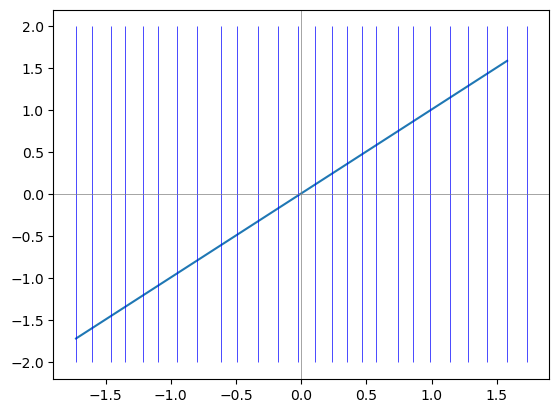

In [75]:
plt.plot(x[idx][:-1], y[idx])
# edges
plt.vlines(x=x[idx], ymin=-2, ymax=2, color='blue', lw=0.5)
# x=0, y=0
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
poly = np.polyfit(x[idx][:-1], y[idx], 1)
print("y=", poly[0], "* x +", poly[1])

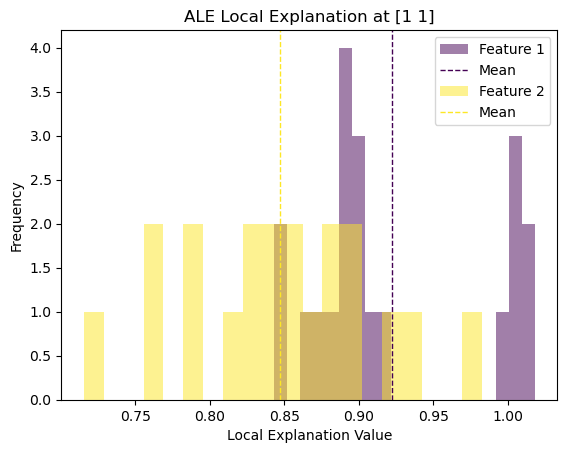

In [76]:
plot_replicated_local_explanations(ale_replications, x_explain, method="ALE")

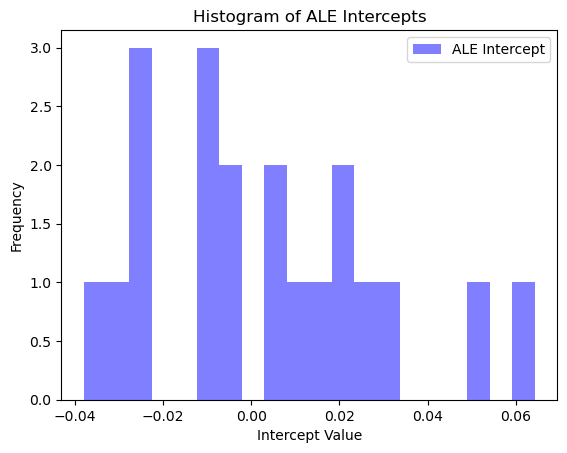

In [77]:
plt.hist(ale_intercepts, bins=20, alpha=0.5, label='ALE Intercept', color='blue')
plt.title("Histogram of ALE Intercepts")
plt.xlabel("Intercept Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

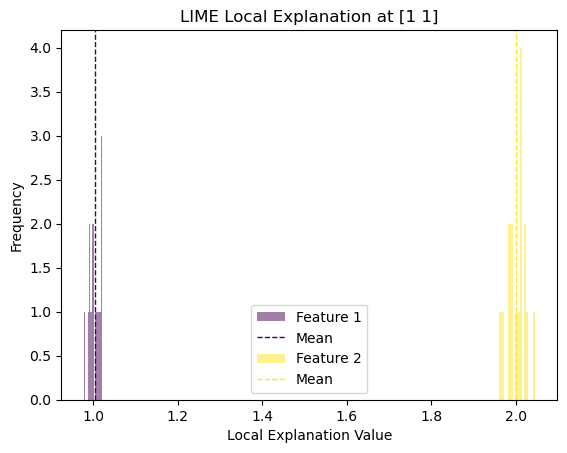

In [78]:
plot_replicated_local_explanations(lime_replications, x_explain, method="LIME")

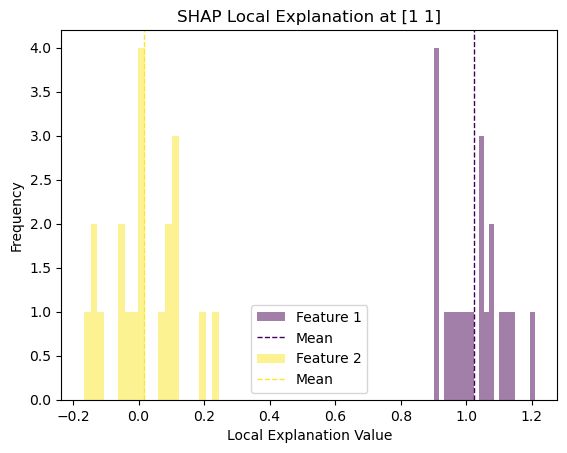

In [79]:
plot_replicated_local_explanations(shap_replications, x_explain, method="SHAP")

## Example 2
Normal DGP with NN Model

In [80]:
# def example_2_dgp(n):
#     u = np.random.uniform(0, 1, n)
#     x1 = u + np.random.normal(0, 0.05, n)
#     x2 = u + np.random.normal(0, 0.05, n)
#     X = np.column_stack((x1, x2))
#     y = x1 + x2 ** 2 + np.random.normal(0, 0.1, n)
#     return X, y

# def example_2_f_factory(X, y):
#     # train a neural network regressor
#     mlp = MLPRegressor(
#         hidden_layer_sizes=(80,),
#         activation='relu',
#         solver='adam',
#         alpha=0.00001,
#         learning_rate='constant',
#         max_iter=1000,
#         random_state=42
#     )
#     mlp.fit(X, y)
#     return lambda X: mlp.predict(X)

# ale_replications, lime_replications, shap_replications = replicate_compared_local_explanations_training(example_2_dgp, example_2_f_factory, x_explain, n=100, m=50)

In [81]:
# 2d scatter plot
X, y = example_2_dgp(100)
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Scatter Plot of Data")
plt.show()

NameError: name 'example_2_dgp' is not defined

In [ ]:
plot_replicated_local_explanations(ale_replications, x_explain, method="ALE")

In [ ]:
plot_replicated_local_explanations(lime_replications, x_explain, method="LIME")

In [ ]:
plot_replicated_local_explanations(shap_replications, x_explain, method="SHAP")